# NLP Assignment: Language Modelling with Poetry (deadline **20.5.2025**)

This assignment will check your basic NLP understanding through the fundamental NLP task of **language modelling**.

You will reiterate on the task with techniques ranging from simple n-gram counting to embeddings and deep learning.


You will work with the same short poetry texts that should be very familiar to you by now:

In [ ]:
!wget -nc https://raw.githubusercontent.com/GustikS/smu-nlp/master/robert_frost.txt
!wget -nc https://raw.githubusercontent.com/GustikS/smu-nlp/master/edgar_allan_poe.txt

File ‘robert_frost.txt’ already there; not retrieving.

File ‘edgar_allan_poe.txt’ already there; not retrieving.



Unless stated otherwise (Ex. 4,5,6), work just with the Robert Frost file for simplicity (Ex. 1,2,3,7,8)

In [ ]:
!head robert_frost.txt

Two roads diverged in a yellow wood,
And sorry I could not travel both
And be one traveler, long I stood
And looked down one as far as I could
To where it bent in the undergrowth; 

Then took the other, as just as fair,
And having perhaps the better claim
Because it was grassy and wanted wear,
Though as for that the passing there


In [ ]:
# Libraries
import nltk
import numpy as np
import pandas as pd
import math
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import normalize
from sklearn.decomposition import TruncatedSVD
from nltk.tokenize import word_tokenize
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
nltk.download('punkt')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

#### **Excercise 1**: Markov Language Model (**2 points**)

1. Create a 1st order Markov (bi-gram) language model
  - work with matrix representation of the model
    - i.e. not dictionaries as we did in the tutorial!
    - hence you'll need to assign indices to the words, too
      - include an extra \<UNK\> token for unseen words
  - correctly handle beginnings and ends of sentences
    - sentence = line (skip empty lines)
  - lower case and properly tokenize your sentences
    - but skip all other text preprocessing

In [ ]:
# Load and tokenize
lines = [line.strip()
          for line in open('robert_frost.txt')
          if line.strip()]

tokenized = [
    ['<s>'] + nltk.word_tokenize(line.lower()) + ['</s>']
    for line in lines
]

# Build vocabulary includin <UNK>
word_counts = Counter(w for sent in tokenized for w in sent)
vocab = ['<UNK>'] + sorted(w for w,c in word_counts.items() if w != '<UNK>')
word2idx = {w:i for i,w in enumerate(vocab)}
V = len(vocab)

# Replace rare or Outofvoc words with <UNK>
def idx_seq(sent):
    return [word2idx.get(w, 0) for w in sent]  # 0 is <UNK>

indexed = [idx_seq(sent) for sent in tokenized]

# Build bigram count matrix
counts = np.zeros((V, V), dtype=np.int64)
for seq in indexed:
    for i in range(len(seq)-1):
        counts[seq[i], seq[i+1]] += 1

# Convert to probability matrix (row‐normalize)
row_sums = counts.sum(axis=1, keepdims=True)
# avoid division by zero
row_sums[row_sums == 0] = 1
P_bigram = counts / row_sums


#### **Excercise 2**: Probability + Smoothing (**2 points**)
1. write a function to obtain probability of a given sentence with your model
    - include the beginning and end mark of the sentence as well
    - test also some other sentences and assure the probability makes sense
      - write down your reasoning!
2. incorporate the add-1 (Laplace) smoothing to account for unseen bi-grams
    - you should have your \<UNK\> for unseen unigrams already
    - calculate prob. of "*the young folk held some hope out to each other.*"

In [ ]:
def sentence_prob(sentence, P, word2idx):

    # Compute P(w1,.....,wn) = pi P(w_i | w_{i-1})

    tokens = ['<s>'] + nltk.word_tokenize(sentence.lower()) + ['</s>']
    idxs = [word2idx.get(t, 0) for t in tokens]
    logp = 0.0
    for i in range(len(idxs)-1):
        logp += math.log(P[idxs[i], idxs[i+1]] + 1e-12)
    return math.exp(logp)

print("Unsmoothed Prob\n")
# Test on four sentences:
for sent in [
    "Nothing gold can stay",
    "The cat sat on the mat",
    "as just as",
    "And there"
]:
    print(f"P('{sent}') = {sentence_prob(sent, P_bigram, word2idx):.2e}")


Unsmoothed Prob

P('Nothing gold can stay') = 1.87e-18
P('The cat sat on the mat') = 1.48e-62
P('as just as') = 2.94e-17
P('And there') = 3.43e-05


->Here, we can see the probability of the 2nd bigram is so low because it appear so less compared to others in corpus and the last one "And there" is commonly used in corpus, that's why the prob is higher comapre to others.

In [ ]:
alpha = 1.0
counts_smooth = counts + alpha
denoms = counts.sum(axis=1, keepdims=True) + alpha * V
P_smooth = counts_smooth / denoms

# Probability of the given sentence:
test_sent = "the young folk held some hope out to each other."
prob_test = sentence_prob(test_sent, P_smooth, word2idx)
print(f"Smoothed P('{test_sent}') = {prob_test:.2e}")


Smoothed P('the young folk held some hope out to each other.') = 1.37e-32


#### **Excercise 3**: Perplexity (**1 points**)
1. write a function fo calculate perplexity of your smoothed model on a given sentence
  - including its beginning and ending
2. find the sentence(s) from the corpus with minimum and maximum perplexity

In [ ]:
def perplexity(sentence, P, word2idx):
    tokens = ['<s>'] + nltk.word_tokenize(sentence.lower()) + ['</s>']
    idxs = [word2idx.get(t, 0) for t in tokens]
    N = len(idxs) - 1
    logp = 0.0
    for i in range(N):
        logp += math.log(P[idxs[i], idxs[i+1]] + 1e-12)
    return math.exp(-logp / N)

# Compute for all Frost sentences:
ppxs = [perplexity(' '.join(sent[1:-1]), P_smooth, word2idx)
        for sent in tokenized]
df_ppx = pd.DataFrame({
    'sentence': [' '.join(sent[1:-1]) for sent in tokenized],
    'perplexity': ppxs
})
# sentences from the corpus with minimum and maximum perplexity
min_sent = df_ppx.loc[df_ppx.perplexity.idxmin()]
max_sent = df_ppx.loc[df_ppx.perplexity.idxmax()]
print("Min perplexity:", min_sent.perplexity, "\n", min_sent.sentence)
print("Max perplexity:", max_sent.perplexity, "\n", max_sent.sentence)


Min perplexity: 43.295809802835976 
 it .
Max perplexity: 1328.52752832652 
 uttered alone


#### **Excercise 4:**  Markov classifier (**4 points**)
Implement your own probabilistic classifier based on your bi-gram language model. That is:
  1. given some classes of sentences, train a separate language model for each class respectively
  2. then classify a given sentence (=sample) based on maximum a-posteriori probability (MAP)
    - i.e. don't forget about the class priors, too!
    - use log probabilities!
    - make sure your smoothing treats all the classes equally!
      - ...think about what happens to the UNK token
  3. evaluate on a task of recognizing sentences from the 2 different poets (Frost vs. Poe)
    - split the sentences (=samples) from each poet into train-test in advance!
      - fixed train-test split 70:30
        - do not shuffle sentences
      - skip empty lines (of course)
 	- report all accuracy values + a confusion matrix

*Note that this is very similar to our previous classification with Naive Bayes, but with bi-grams instead of unigrams.*

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Load and split both corpora (70:30 no shuffle)
def load_poet(path):
    with open(path, encoding='utf-8') as f:
        S = [line.strip() for line in f if line.strip()]
    toks = [['<s>'] + nltk.word_tokenize(l.lower()) + ['</s>']
            for l in S]
    return toks

frost = load_poet('robert_frost.txt')
poe   = load_poet('edgar_allan_poe.txt')

def train_test_split_no_shuffle(data, train_frac=0.7):
    n = int(len(data)*train_frac)
    return data[:n], data[n:]

f_train, f_test = train_test_split_no_shuffle(frost)
p_train, p_test = train_test_split_no_shuffle(poe)

# Build separate count + smooth P matrices for each class
def build_P(sentences, alpha=1.0):
    # build raw counts in float
    C = np.zeros((V, V), dtype=np.float64)
    for sent in sentences:
        idxs = [word2idx.get(w,0) for w in sent]
        for i in range(len(idxs)-1):
            C[idxs[i], idxs[i+1]] += 1
    # now safe to add a float
    C += alpha
    # row‐sums (each row sums to original count + alpha*V)
    D = C.sum(axis=1, keepdims=True)
    return C / D


P_frost = build_P(f_train)
P_poe   = build_P(p_train)

# Priors
prior_f = len(f_train) / (len(f_train)+len(p_train))
prior_p = 1 - prior_f

# Classify test sentences
def log_posterior(sent, P_model, prior):
    tokens = ['<s>'] + nltk.word_tokenize(sent.lower()) + ['</s>']
    idxs = [word2idx.get(w,0) for w in tokens]
    lp = math.log(prior)
    for i in range(len(idxs)-1):
        lp += math.log(P_model[idxs[i],idxs[i+1]] + 1e-12)
    return lp

y_true, y_pred = [], []
for sent in [' '.join(s[1:-1]) for s in f_test]:
    y_true.append('Frost')
    lp_f = log_posterior(sent, P_frost, prior_f)
    lp_p = log_posterior(sent, P_poe,   prior_p)
    y_pred.append('Frost' if lp_f > lp_p else 'Poe')

for sent in [' '.join(s[1:-1]) for s in p_test]:
    y_true.append('Poe')
    lp_f = log_posterior(sent, P_frost, prior_f)
    lp_p = log_posterior(sent, P_poe,   prior_p)
    y_pred.append('Frost' if lp_f > lp_p else 'Poe')

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_true, y_pred,
      labels=['Frost','Poe']))


Accuracy: 0.9505409582689336
Confusion matrix:
 [[419  12]
 [ 20 196]]


#### **Excercise 5**: PPMI word-word cooccurence (**1 points**)
1. Create a word-word co-occurence matrix from all the text of both the poets altogether
  - use a sliding window of size 5 (2 left + 2 right context words)
    - remember that you can reuse existing solutions...
2. Post-process the matrix with PPMI

In [ ]:
# 1. Build co-occurrence counts (window=2)
co_counts = np.zeros((V, V), dtype=np.int64)
for sent in tokenized:
    idxs = [word2idx[w] for w in sent]
    for i, wi in enumerate(idxs):
        for j in range(max(0,i-2), min(len(idxs), i+3)):
            if i!=j:
                wj = idxs[j]
                co_counts[wi, wj] += 1

# 2. Compute PPMI
N = co_counts.sum()
row = co_counts.sum(axis=1, keepdims=True)
col = co_counts.sum(axis=0, keepdims=True)
# avoid zero
expected = row.dot(col) / N
with np.errstate(divide='ignore', invalid='ignore'):
    pmi = np.log2(co_counts * N / expected)
pmi[np.isneginf(pmi)] = 0
PPMI = np.maximum(pmi, 0)


#### **Excercise 6**: Word embeddings (**1 points**)
1. Extract 8-dimensional word embeddings from your PPMI matrix
  - using the truncated SVD matrix decomposition
2. Plot them in 2D with word labels

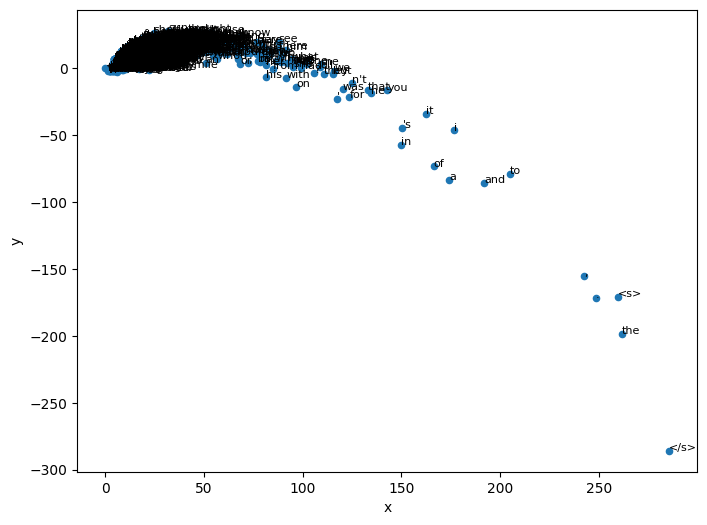

In [ ]:
# 1. Compute PPMI with NaN/inf handling
N = co_counts.sum()
row = co_counts.sum(axis=1, keepdims=True)
col = co_counts.sum(axis=0, keepdims=True)
expected = row.dot(col) / N

with np.errstate(divide='ignore', invalid='ignore'):
    pmi = np.log2(co_counts * N / expected)

# replace NaN, +inf, -inf with 0
pmi = np.nan_to_num(pmi, nan=0.0, posinf=0.0, neginf=0.0)

PPMI = np.maximum(pmi, 0.0)

# 2. 8-dim SVD embeddings
svd = TruncatedSVD(n_components=8, random_state=0)
emb8 = svd.fit_transform(PPMI)  # shape (V, 8)

# 3. Plot first two dimensions
df_emb = pd.DataFrame({
    'x': emb8[:, 0],
    'y': emb8[:, 1],
    'word': vocab
})

ax = df_emb.plot.scatter('x', 'y', figsize=(8, 6))
for _, r in df_emb.iterrows():
    ax.text(r['x'] + 1e-3, r['y'] + 1e-3, r['word'], fontsize=8)


#### **Excercise 7:** LSTM Language Model (**3 points**)
1. Formulate a proper dataset for language modelling on longer sequences from the text
  - beyond the n-gram scope, use 10 consecutive words
2. Create a suitable LSTM-based language model
3. Initialize the embedding layer of your model with your "pretrained" SVD embeddings
4. Train the model in a suitable fashion

In [ ]:
# 1. Prepare dataset: sequences of length 10 -> next word
seq_len = 10
all_idxs = [idx for sent in indexed for idx in sent]
inputs, targets = [], []
for i in range(len(all_idxs)-seq_len):
    inputs.append(all_idxs[i:i+seq_len])
    targets.append(all_idxs[i+seq_len])

class LMData(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return self.X[i], self.y[i]

dataset = LMData(inputs, targets)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

# 2. Define model
class LSTMLM(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, emb_dim)
        # initialize with SVD embeddings
        self.embed.weight.data.copy_(torch.tensor(emb8, dtype=torch.float))
        self.lstm = nn.LSTM(emb_dim, hid_dim, batch_first=True)
        self.out = nn.Linear(hid_dim, vocab_size)
    def forward(self, x):
        emb = self.embed(x)
        o, _ = self.lstm(emb)
        return self.out(o[:,-1,:])  # predict next word

model = LSTMLM(V, emb_dim=8, hid_dim=128)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# 3. Train
for epoch in range(10):
    total_loss = 0
    for xb, yb in loader:
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1} loss {total_loss/len(loader):.4f}")


Epoch 1 loss 5.3830
Epoch 2 loss 4.4993
Epoch 3 loss 4.2560
Epoch 4 loss 4.0773
Epoch 5 loss 3.9351
Epoch 6 loss 3.8011
Epoch 7 loss 3.6789
Epoch 8 loss 3.5600
Epoch 9 loss 3.4513
Epoch 10 loss 3.3427


 #### **Excercise 8**: Sampling (**1 point**)
1. Sample some text from your models w.r.t. to the output (next) word probability distribution
  - for both bigram and LSTM models - which is better?

2. Paste your best "poem" here:

In [64]:
import random

# (a) Bigram sampling
def sample_bigram(n=20):
    w = word2idx['<s>']; sent=[]
    for _ in range(n):
        probs = P_smooth[w]
        next_w = np.random.choice(V, p=probs)
        if vocab[next_w]=='</s>': break
        sent.append(vocab[next_w])
        w = next_w
    return ' '.join(sent)

print("Bigram sample:", sample_bigram())

# (b) LSTM sampling
def sample_lstm(n=20, temp=1.0):
    # start with seq of <s>
    seq = [word2idx['<s>']] * seq_len
    out = []
    model.eval()
    with torch.no_grad():
        for _ in range(n):
            x = torch.tensor([seq[-seq_len:]], dtype=torch.long)
            logits = model(x)[0] / temp
            probs = torch.softmax(logits, dim=0).numpy()
            w = np.random.choice(V, p=probs)
            if vocab[w]=='</s>': break
            out.append(vocab[w])
            seq.append(w)
    return ' '.join(out)

print("LSTM sample:", sample_lstm())


Bigram sample: ploughed books dead happened adding her clearing defeat bowed blind first places emptied morning started threatener pecker-fretted 'tell troubling meet
LSTM sample: have have 'd was rain . get


Bigram is giving better results. I can use Bidirectional-LSTM or GRU-LSTM to get better results. This type of poem I am getting from the Bigram, "ploughed books dead happened adding her clearing defeat bowed blind first places emptied morning started threatener pecker-fretted 'tell troubling meet". I am not sure if this is the best or not, but this looks better. Who knows, some poet may find it deep and meaningful.

# **Notes**

If this seems like a lot of work, reiterate through the tutorials (which is the purpose, anyway) - we did most of this already!
  - i.e., I don't expect you to be overly creative, you can find all the pieces in the tutorial notebooks
  - but feel free to write a more efficient/clean/suitable code from scratch
  - only the libraries we used in the tutorials are allowed
  - teamwork is forbidden!
  - chatGPT is allowed

Before submitting:
  - make sure your code is runnable (in Colab)!
  - comment your code at least a bit, make it readable!
  - add printouts after every excercise
  - submit just the notebook as a single file (filename = username)


I will only evaluate *correctness* of the solutions, not quality of the models
  - i.e. no need to spent too much time with text preprocessing or hyperparameter tuning (LSTM)

# **Bonus points**
You can recover some of the potentially lost points here, but you can't reach more than 15 points in total from this assignment
  - *explicitly mark the bonus points you consider as fullfilled!*
<br/><br/>

1. (2p) Use a different (larger) textual corpus of poems
  - e.g. Corpus of Czech Verse, collected at the Institute of Czech Literature at Czech Academy of Sciences
    - available at https://github.com/versotym/corpusCzechVerse
    - just be careful about czech character encoding

2. (7p) An alternative task - create a "whisperer" (bot player) for the popular game ["Kryci jmena"](https://krycijmena.cz/) based on word embeddings
  - i.e. automatically search for words that would cover (be related/close to) subsets of the "positive" words, while trying to avoid the "negative" words
  - this will be graded based on both quality of the approach and the result

In [ ]:
# Corpus of Czech Verse
!git clone https://github.com/versotym/corpusCzechVerse

fatal: destination path 'corpusCzechVerse' already exists and is not an empty directory.


In [65]:
import json
from os import listdir
path = 'corpusCzechVerse/ccv/'

books = []
files = [f for f in listdir(path)]
for i, f in enumerate(sorted(files)):
    print(f)
    book = open(path+f)
    books.append(json.load(book))

    break

FileNotFoundError: [Errno 2] No such file or directory: 'corpusCzechVerse/ccv/'

In [ ]:
i=0
book = books[i]

for poem in book:
    author = poem['p_author']['name']
    title = poem['biblio']['p_title']
    print('------' + title + '------\n')
    body = poem['body']
    for text in body:
        for line in text:
            print(line['text'])
        print('')
    break

------JAROSLAVU VRCHLICKÉMU------

Tvá loď jde po vysokém moři,
v ně brázdu jako stříbro reje,
svou přídu v modré vlny noří
a bok svůj pěnné do peřeje.

Tvá lana sviští, plachty duní
a třepe vlajka. V noční chvíli
zříš magický svit mořských tůní,
a ve snu, Albatros jak pílí.

Já samotním, jsem na ostrově,
ohýnek topím, rybku lově
zasedám na břeh za večera.

Dým v kotoučích se modrých krade,
kdes písklo ptáče, ještě mladé,
tma na mne hrozí z pološera.

